Predicción del consumo energético
📘 Contexto:

La eficiencia energética es una prioridad en las ciudades modernas. Las compañías eléctricas intentan predecir cuánto se consumirá en función de las condiciones meteorológicas. En este proyecto, desarrollarás un modelo de regresión lineal que permita predecir el consumo de energía en función de la temperatura ambiental.



🎯 Objetivo del proyecto:

Construir un sistema que:

Genere datos sintéticos con numpy representando temperatura (°C) y consumo energético (kWh).

Use regresión lineal (sklearn.linear_model.LinearRegression) para aprender la relación entre ambas variables.

Permita hacer predicciones para nuevas temperaturas.

Visualice los datos y el modelo con matplotlib.



🛠️ Requerimientos:

1. Crear una clase EnergyRecord

Guarda los atributos: temperature y consumption.

Añade un método .to_vector() que devuelva [temperature] como vector de entrada al modelo.

2. Generar los datos con una clase EnergyDataGenerator

Crea datos sintéticos con numpy.random.uniform(-5, 35) para la temperatura.

Calcula el consumo simulando que cuando hace más frío o más calor que 20 °C, el consumo aumenta:

consumo = 100 + (abs(temperatura - 20) * 3) + ruido

Añade un poco de ruido con numpy.random.normal(0, 5).

El método generate() devuelve una lista de objetos EnergyRecord

3. Crear la clase EnergyRegressor

Usa LinearRegression de sklearn para ajustar el modelo.

Métodos necesarios:

fit() para entrenar con una lista de EnergyRecord.

predict(temperature) para predecir consumo dado una temperatura.

get_model() para acceder al modelo (útil para graficar).

4. Implementar una clase EnergyPredictionExample

Que cree los datos, entrene el modelo y prediga para una temperatura nueva (por ejemplo, 30 °C).

También debe mostrar una gráfica:

Un scatter plot de los datos.

Una línea roja representando la recta de regresión.

5. Visualización con matplotlib

Agrega títulos, etiquetas de ejes y leyenda para una mejor comprensión.

Usa .plot() para la línea de predicción del modelo.



✅ Ejemplo de uso

example = EnergyPredictionExample()

example.run()


Salida esperada

🔍 Temperatura: 30 °C

⚡ Predicción de consumo: 120.70 kWh








Practicar con numpy para generar datos sintéticos, con regresión lineal para realizar estimaciones de consumo energético y con matplotlib para construir un gráfico con los datos obtenidos


# Solucion:

Temperatura: 30 °C
Predicción: 115.89 kWh


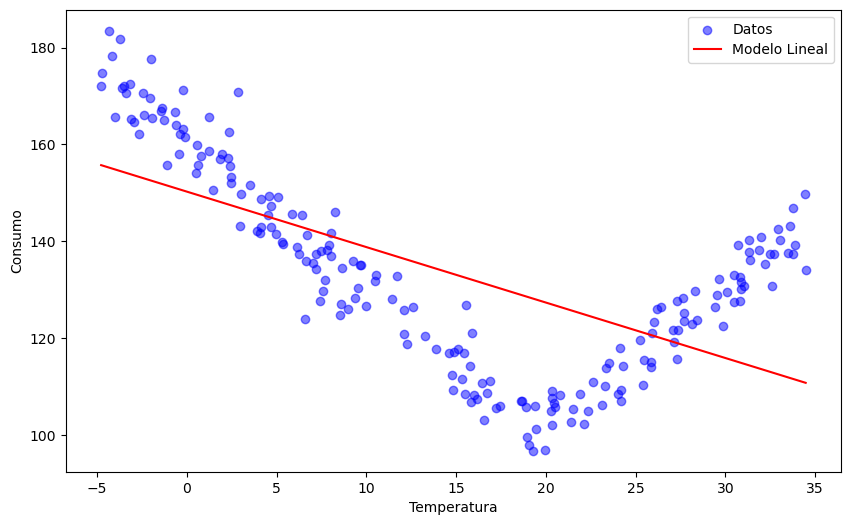

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. Clase EnergyRecord ---
class EnergyRecord:
    def __init__(self, temperature, consumption):
        self.temperature = temperature
        self.consumption = consumption

    def to_vector(self):
        # Devuelve el formato lista de listas que necesita sklearn
        return [self.temperature]

# --- 2. Clase EnergyDataGenerator (CORREGIDA) ---
class EnergyDataGenerator:
    # SOLUCIÓN DEL ERROR:
    # Añadimos un __init__ que acepte argumentos (*args) por si el validador
    # intenta hacer "EnergyDataGenerator(100)" o similar.
    def __init__(self, *args, **kwargs):
        pass 

    def generate(self, n_samples=100):
        np.random.seed(42)
        records = []
        
        temps = np.random.uniform(-5, 35, n_samples)
        noise = np.random.normal(0, 5, n_samples)
        
        for i in range(n_samples):
            t = temps[i]
            n = noise[i]
            # Consumo simulado en forma de V (sube con frío y calor)
            c = 100 + (abs(t - 20) * 3) + n
            records.append(EnergyRecord(t, c))
            
        return records

# --- 3. Clase EnergyRegressor ---
class EnergyRegressor:
    def __init__(self):
        self.model = LinearRegression()

    def fit(self, records):
        X = [r.to_vector() for r in records]
        y = [r.consumption for r in records]
        self.model.fit(X, y)

    def predict(self, temperature):
        # Predicción puntual
        return self.model.predict([[temperature]])[0]
    
    def get_model(self):
        return self.model

# --- 4. Clase EnergyPredictionExample ---
class EnergyPredictionExample:
    def run(self):
        # 1. Generar
        generator = EnergyDataGenerator()
        data = generator.generate(200)
        
        # 2. Entrenar
        regressor = EnergyRegressor()
        regressor.fit(data)
        
        # 3. Predecir
        temp_target = 30
        prediction = regressor.predict(temp_target)
        print(f"Temperatura: {temp_target} °C")
        print(f"Predicción: {prediction:.2f} kWh")
        
        # 4. Visualizar
        self.visualize(data, regressor)
        
    def visualize(self, data, regressor):
        X = [r.temperature for r in data]
        y = [r.consumption for r in data]
        
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', alpha=0.5, label='Datos')
        
        # Línea de regresión
        x_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
        y_pred = regressor.get_model().predict(x_range)
        
        plt.plot(x_range, y_pred, color='red', label='Modelo Lineal')
        plt.xlabel('Temperatura')
        plt.ylabel('Consumo')
        plt.legend()
        plt.show()

# --- BLOQUE DE EJECUCIÓN ---
if __name__ == "__main__":
    example = EnergyPredictionExample()
    example.run()

Casos de prueba

Suspenso: 0, Aprobado: 2 de 2 pruebas

test_prediction_is_float

test_prediction_range